# MODELO XGBOOST: CLASIFICACIÓN MULTILABEL DE PATOLOGÍAS CEREBRALES

## Objetivo
Entrenar y evaluar un modelo XGBoost para clasificación multilabel de 4 patologías (**hemorragia, ACV, desviación de línea media y fractura compleja de cráneo**) a partir de texto clínico (campo `Hallazgos`), utilizando **exactamente** la misma configuración experimental que los modelos baseline (SVM Linear, Random Forest, Logistic Regression, Naive Bayes).

## Diseño experimental
- **Representación**: TF-IDF (`max_features=200`, `ngram_range=(1,2)`, `min_df=5`, `max_df=0.8`)
- **Split**: 80/20 estratificado (`random_state=42`)
- **Estrategia multilabel**: One-vs-Rest (un clasificador binario por patología)
- **Métricas**: F1-macro, Recall-macro, Precision-macro, F1 por clase, Cohen's Kappa
- **Validación**: K-Fold estratificado (K=5)
- **Secciones**: (1) XGBoost base, (2) XGBoost con `scale_pos_weight` calculado desde train

## 1. Importaciones y configuración

In [37]:
from dotenv import load_dotenv
import os
import re

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [38]:
# =============================================================================
# IMPORTACIONES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost
from xgboost import XGBClassifier

# Sklearn: preprocesamiento, evaluación y validación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Configuración visual y reproducibilidad
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

print("Importaciones completadas")

Importaciones completadas


## 2. Carga de datos y vectorización TF-IDF

Se utiliza la misma configuración de TF-IDF que en el notebook de Modelos Tradicionales para garantizar comparabilidad directa:
- `max_features=200`, `ngram_range=(1,2)`, `min_df=5`, `max_df=0.8`
- Stopwords personalizadas en español
- Vectorizador ajustado **exclusivamente** con datos de entrenamiento

In [39]:
# =============================================================================
# CARGA DE DATOS
# =============================================================================

df = pd.read_excel('../data/rad_criticos.xlsx')

print("=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
print(f"Total de registros: {len(df)}")
print(f"Columnas: {df.shape[1]}")

# Definir patologías (etiquetas multilabel)
patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
print(f"\nPatologías a clasificar: {patologias}")


INFORMACIÓN DEL DATASET
Total de registros: 952
Columnas: 15

Patologías a clasificar: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


In [40]:
# =============================================================================
# ETIQUETADO DE PATOLOGÍAS (generado automáticamente desde Hallazgos + Opinión)
# =============================================================================

def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """Detecta patologías con análisis de contexto robusto (ventana de negación)."""
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_negativos = keywords_negativos or [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'sin cambios','estable','estables','resolucion','resolución'
    ]
    negaciones_contextuales = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de',
        'negativo para','negativa para'
    ]
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        keyword_encontrada = next((kw for kw in keywords_ordenadas if kw in oracion), None)
        if not keyword_encontrada:
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_negativos):
            continue
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        return 1
    return 0

texto_etiquetado = df['Hallazgos'] + ' ' + df['Opinión']

keywords = {
    'acv': [
        'infarto cerebral','infarto isquemico','accidente cerebrovascular',
        'hipodensidad sugestiva de isquemia','zona de isquemia',
        'area de isquemia','evento isquemico','ictus','acv','isquemia'
    ],
    'hemorragia': [
        'hemorragia subaracnoidea','hemorragia intraparenquimatosa',
        'hemorragia intraventricular','hematoma subdural','hematoma epidural',
        'hematoma intraparenquimatoso','sangrado intraparenquimatoso',
        'coleccion hematica','hemorragia','hematoma','sangrado'
    ],
    'desviacion_linea_media': [
        'desviacion de la linea media','desviacion linea media','linea media desplazada',
        'desplazamiento de la linea media','efecto de masa con desviacion',
        'shift de linea media','herniacion subfalcina','hernia subfalcina'
    ],
    'fractura_compleja_craneo': [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo'
    ]
}

for pat, kws in keywords.items():
    df[pat] = texto_etiquetado.apply(lambda t: detectar_patologia_robusta(t, kws))

print("Distribución de etiquetas generadas:")
for p in ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")


Distribución de etiquetas generadas:
  acv         :   323  (33.9%)
  hemorragia  :   813  (85.4%)
  desviacion_linea_media:   129  (13.6%)
  fractura_compleja_craneo:    30  (3.2%)


In [41]:
# =============================================================================
# DISTRIBUCIÓN + SPLIT + VECTORIZACIÓN TF-IDF
# =============================================================================

print("\nDistribución de clases generadas (positivos):")
for pat in patologias:
    n_pos = df[pat].sum()
    print(f"  {pat:12s}: {n_pos:3d} positivos ({n_pos/len(df)*100:.1f}%)")

# Texto de entrada y etiquetas multilabel
X_text = df['Hallazgos'].astype(str)
y = df[patologias].values

# Split estratificado 80/20
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=df[patologias[0]].values
)

print("=" * 60)
print("DIVISIÓN TRAIN/TEST")
print("=" * 60)
print(f"Train: {len(X_text_train)} muestras")
print(f"Test:  {len(X_text_test)} muestras")

# Stopwords
stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

# Vectorización TF-IDF — fit SOLO en train
vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X_train = vectorizer.fit_transform(X_text_train)
X_test  = vectorizer.transform(X_text_test)

print(f"\nVectorización TF-IDF (fit solo en train):")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Features (términos TF-IDF): {X_train.shape[1]}")

print(f"\nDistribución de clases en TRAIN:")
for idx, pat in enumerate(patologias):
    n_pos = y_train[:, idx].sum()
    n_neg = len(y_train) - n_pos
    print(f"  {pat:12s}: {n_pos:3.0f} pos / {n_neg:3.0f} neg (ratio 1:{n_neg/n_pos:.2f})")



Distribución de clases generadas (positivos):
  acv         : 323 positivos (33.9%)
  hemorragia  : 813 positivos (85.4%)
  desviacion_linea_media: 129 positivos (13.6%)
  fractura_compleja_craneo:  30 positivos (3.2%)
DIVISIÓN TRAIN/TEST
Train: 761 muestras
Test:  191 muestras

Vectorización TF-IDF (fit solo en train):
  X_train: (761, 200)
  X_test:  (191, 200)
  Features (términos TF-IDF): 200

Distribución de clases en TRAIN:
  acv         : 258 pos / 503 neg (ratio 1:1.95)
  hemorragia  : 648 pos / 113 neg (ratio 1:0.17)
  desviacion_linea_media: 108 pos / 653 neg (ratio 1:6.05)
  fractura_compleja_craneo:  21 pos / 740 neg (ratio 1:35.24)


## 3. XGBoost Base (sin ajuste de desbalance)

Entrenamiento de XGBoost con parámetros por defecto, usando `OneVsRestClassifier` para el problema multilabel. Esta versión **no aplica oversampling ni ajuste de `scale_pos_weight`**, sirviendo como punto de referencia para medir el efecto posterior del balanceo.

### Hiperparámetros base:
- `n_estimators=100` (comparable con Random Forest)
- `max_depth=6` (default de XGBoost)
- `learning_rate=0.3` (default)
- `eval_metric='logloss'` (clasificación binaria)
- `random_state=42` (reproducibilidad)

In [42]:
# =============================================================================
# ENTRENAMIENTO XGBOOST BASE (SIN AJUSTE DE DESBALANCE)
# =============================================================================

print("=" * 70)
print("XGBOOST BASE - CLASIFICACIÓN MULTILABEL (ONE-VS-REST)")
print("=" * 70)

# Definir clasificador base XGBoost
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Entrenar un clasificador por patología (One-vs-Rest manual para mayor control)
modelos_base = {}
predicciones_base = {}
resultados_base = []

for idx, patologia in enumerate(patologias):
    print(f"\n{'─'*50}")
    print(f"Entrenando: {patologia.upper()}")
    print(f"{'─'*50}")
    
    # Extraer etiquetas binarias para esta patología
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    # Clonar y entrenar
    modelo = clone(xgb_base)
    modelo.fit(X_train, y_train_pat)
    
    # Predecir en test
    y_pred = modelo.predict(X_test)
    
    # Calcular métricas
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    print(f"  F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f}")
    
    # Almacenar modelo y predicciones
    modelos_base[patologia] = modelo
    predicciones_base[patologia] = {
        'y_pred': y_pred,
        'y_test': y_test_pat
    }
    
    resultados_base.append({
        'Patología': patologia,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa
    })

# Calcular métricas MACRO (promedio de las 4 patologías)
f1_macro_base = np.mean([r['F1'] for r in resultados_base])
recall_macro_base = np.mean([r['Recall'] for r in resultados_base])
precision_macro_base = np.mean([r['Precision'] for r in resultados_base])
kappa_macro_base = np.mean([r['Kappa'] for r in resultados_base])

print(f"\n{'='*70}")
print(f"MÉTRICAS MACRO (XGBoost Base)")
print(f"{'='*70}")
print(f"  F1-macro:        {f1_macro_base:.4f}")
print(f"  Recall-macro:    {recall_macro_base:.4f}")
print(f"  Precision-macro: {precision_macro_base:.4f}")
print(f"  Kappa-macro:     {kappa_macro_base:.4f}")
print(f"{'='*70}")

XGBOOST BASE - CLASIFICACIÓN MULTILABEL (ONE-VS-REST)

──────────────────────────────────────────────────
Entrenando: ACV
──────────────────────────────────────────────────
  F1: 0.943 | Recall: 0.892 | Precision: 1.000 | Kappa: 0.916

──────────────────────────────────────────────────
Entrenando: HEMORRAGIA
──────────────────────────────────────────────────
  F1: 0.973 | Recall: 0.982 | Precision: 0.964 | Kappa: 0.789

──────────────────────────────────────────────────
Entrenando: DESVIACION_LINEA_MEDIA
──────────────────────────────────────────────────
  F1: 0.500 | Recall: 0.381 | Precision: 0.727 | Kappa: 0.459

──────────────────────────────────────────────────
Entrenando: FRACTURA_COMPLEJA_CRANEO
──────────────────────────────────────────────────
  F1: 0.333 | Recall: 0.222 | Precision: 0.667 | Kappa: 0.317

MÉTRICAS MACRO (XGBoost Base)
  F1-macro:        0.6873
  Recall-macro:    0.6193
  Precision-macro: 0.8396
  Kappa-macro:     0.6205


## 4. Evaluación detallada del modelo base

Reportes de clasificación por patología, matrices de confusión y tabla resumen comparativa.

REPORTES DE CLASIFICACIÓN POR PATOLOGÍA (XGBoost Base)

──────────────────────────────────────────────────
ACV
──────────────────────────────────────────────────
              precision    recall  f1-score   support

     Sin ACV      0.947     1.000     0.973       126
         ACV      1.000     0.892     0.943        65

    accuracy                          0.963       191
   macro avg      0.974     0.946     0.958       191
weighted avg      0.965     0.963     0.963       191

  Cohen's Kappa: 0.9162

──────────────────────────────────────────────────
HEMORRAGIA
──────────────────────────────────────────────────
                precision    recall  f1-score   support

Sin hemorragia      0.870     0.769     0.816        26
    Hemorragia      0.964     0.982     0.973       165

      accuracy                          0.953       191
     macro avg      0.917     0.876     0.895       191
  weighted avg      0.951     0.953     0.952       191

  Cohen's Kappa: 0.7894

─────────

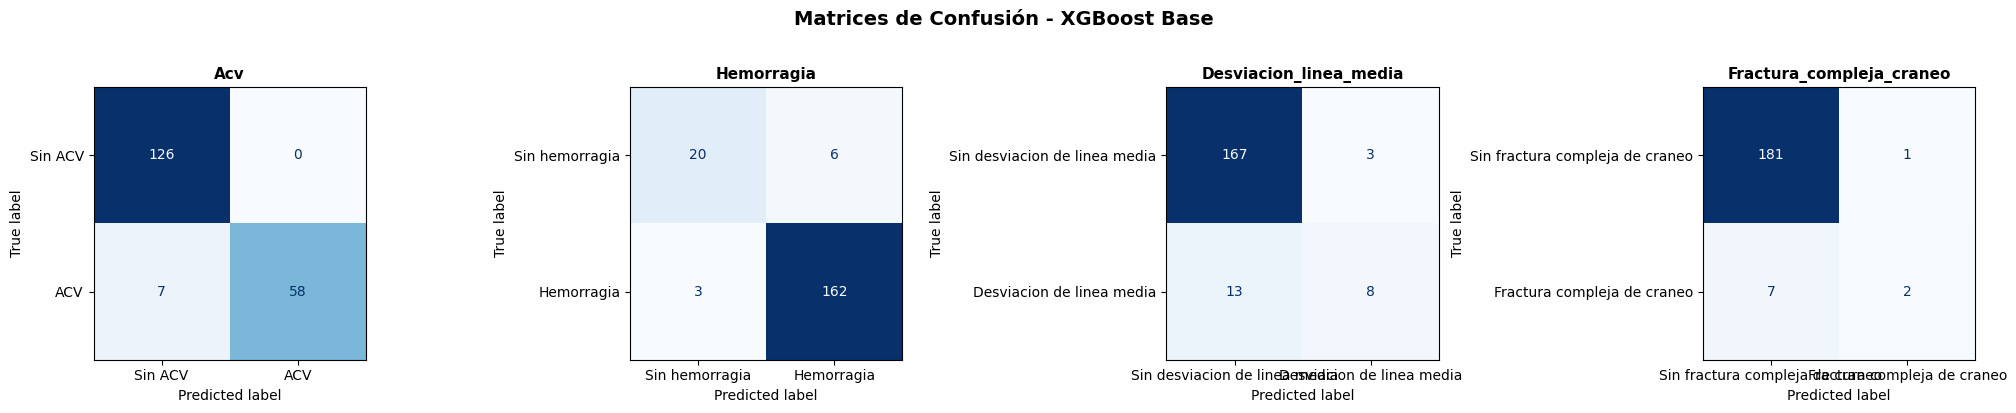

In [43]:
# =============================================================================
# REPORTES DE CLASIFICACIÓN Y MATRICES DE CONFUSIÓN (XGBOOST BASE)
# =============================================================================

print("=" * 70)
print("REPORTES DE CLASIFICACIÓN POR PATOLOGÍA (XGBoost Base)")
print("=" * 70)

# Etiquetas descriptivas por patología
etiquetas_dict = {
    'hemorragia': ['Sin hemorragia', 'Hemorragia'],
    'acv':        ['Sin ACV', 'ACV'],
    'fractura_compleja_craneo':   ['Sin fractura compleja de craneo', 'Fractura compleja de craneo'],
    'desviacion_linea_media':       ['Sin desviacion de linea media', 'Desviacion de linea media']
}

for patologia in patologias:
    y_test_pat = predicciones_base[patologia]['y_test']
    y_pred_pat = predicciones_base[patologia]['y_pred']
    etiquetas  = etiquetas_dict[patologia]
    
    print(f"\n{'─'*50}")
    print(f"{patologia.upper()}")
    print(f"{'─'*50}")
    print(classification_report(y_test_pat, y_pred_pat, 
                                 target_names=etiquetas, digits=3))
    kappa_pat = cohen_kappa_score(y_test_pat, y_pred_pat)
    print(f"  Cohen's Kappa: {kappa_pat:.4f}")

# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, patologia in enumerate(patologias):
    y_test_pat = predicciones_base[patologia]['y_test']
    y_pred_pat = predicciones_base[patologia]['y_pred']
    etiquetas  = etiquetas_dict[patologia]
    
    cm = confusion_matrix(y_test_pat, y_pred_pat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False, values_format='d')
    axes[idx].set_title(f"{patologia.capitalize()}", fontweight='bold', fontsize=11)

plt.suptitle("Matrices de Confusión - XGBoost Base", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [44]:
# =============================================================================
# TABLA RESUMEN DE MÉTRICAS (XGBOOST BASE)
# =============================================================================

print("=" * 70)
print("TABLA RESUMEN: XGBOOST BASE")
print("=" * 70)

df_resultados_base = pd.DataFrame(resultados_base)
df_resultados_base = df_resultados_base.set_index('Patología')

print("\nMétricas por patología:")
print(df_resultados_base.round(4).to_string())

# Fila de promedios macro
print(f"\n{'─'*50}")
print(f"{'MACRO':<12s}  Precision: {precision_macro_base:.4f}  "
      f"Recall: {recall_macro_base:.4f}  "
      f"F1: {f1_macro_base:.4f}  "
      f"Kappa: {kappa_macro_base:.4f}")
print(f"{'─'*50}")

# Comparación rápida con baselines previos (valores del notebook 2)
print(f"\n{'='*70}")
print("REFERENCIA: MEJORES BASELINES (Notebook 2 - Modelos Tradicionales)")
print("=" * 70)
print(f"  SVM Linear:          F1-macro = 0.909 | Recall-macro = 0.931 | Precision-macro = 0.893")
print(f"  Random Forest:       F1-macro = 0.902 | Recall-macro = 0.872 | Precision-macro = 0.946")
print(f"  Logistic Regression: F1-macro = 0.890 | Recall-macro = 0.926 | Precision-macro = 0.862")
print(f"\n  XGBoost Base:        F1-macro = {f1_macro_base:.3f} | Recall-macro = {recall_macro_base:.3f} | Precision-macro = {precision_macro_base:.3f}")
print("=" * 70)

TABLA RESUMEN: XGBOOST BASE

Métricas por patología:
                          Precision  Recall      F1   Kappa
Patología                                                  
acv                          1.0000  0.8923  0.9431  0.9162
hemorragia                   0.9643  0.9818  0.9730  0.7894
desviacion_linea_media       0.7273  0.3810  0.5000  0.4591
fractura_compleja_craneo     0.6667  0.2222  0.3333  0.3172

──────────────────────────────────────────────────
MACRO         Precision: 0.8396  Recall: 0.6193  F1: 0.6873  Kappa: 0.6205
──────────────────────────────────────────────────

REFERENCIA: MEJORES BASELINES (Notebook 2 - Modelos Tradicionales)
  SVM Linear:          F1-macro = 0.909 | Recall-macro = 0.931 | Precision-macro = 0.893
  Random Forest:       F1-macro = 0.902 | Recall-macro = 0.872 | Precision-macro = 0.946
  Logistic Regression: F1-macro = 0.890 | Recall-macro = 0.926 | Precision-macro = 0.862

  XGBoost Base:        F1-macro = 0.687 | Recall-macro = 0.619 | Precisio

---

## 5. Validación Cruzada Estratificada con Pipeline (K=5)

### Diseño metodológico

Para garantizar la ausencia de data leakage en la estimación de rendimiento fuera de muestra, se emplea un `sklearn.pipeline.Pipeline` que encapsula **en un único objeto estimable** el vectorizador TF-IDF y el clasificador XGBoost. Al pasar este Pipeline a `cross_val_score`, scikit-learn ejecuta en cada fold las operaciones siguientes, en estricto orden:

1. `pipeline.fit(X_train_fold)` — Ajusta el vocabulario TF-IDF y entrena el clasificador **exclusivamente** con los datos de entrenamiento del fold.
2. `pipeline.predict(X_val_fold)` — Transforma el texto *crudo* del fold de validación usando el vocabulario aprendido en el paso anterior, y genera predicciones.



VALIDACIÓN CRUZADA CON PIPELINE (K=5) — IMPLEMENTACIÓN OFICIAL

Flujo por fold:
  1. pipeline.fit(X_train_fold)  → TF-IDF ajustado solo en train del fold
  2. pipeline.predict(X_val_fold) → texto crudo transformado con vocab. del fold
  Entrada: X_text (texto crudo) — sin pre-vectorización externa



  acv           F1: 0.973 ± 0.016  |  Recall: 0.957 ± 0.025  |  Precision: 0.991 ± 0.018
  hemorragia    F1: 0.962 ± 0.010  |  Recall: 0.973 ± 0.015  |  Precision: 0.951 ± 0.007
  desviacion_linea_media  F1: 0.485 ± 0.173  |  Recall: 0.428 ± 0.183  |  Precision: 0.584 ± 0.151
  fractura_compleja_craneo  F1: 0.182 ± 0.171  |  Recall: 0.133 ± 0.125  |  Precision: 0.373 ± 0.397

RESULTADOS GLOBALES (Pipeline CV — valores oficiales)
  F1-macro     :  0.651 ± 0.092
  Recall-macro :  0.623
  Precision-macro: 0.725

  Referencia — SVM Linear CV (baseline):  0.898 ± 0.019
  XGBoost Pipeline CV:                    0.651 ± 0.092  (Δ = -0.247 vs SVM Linear)


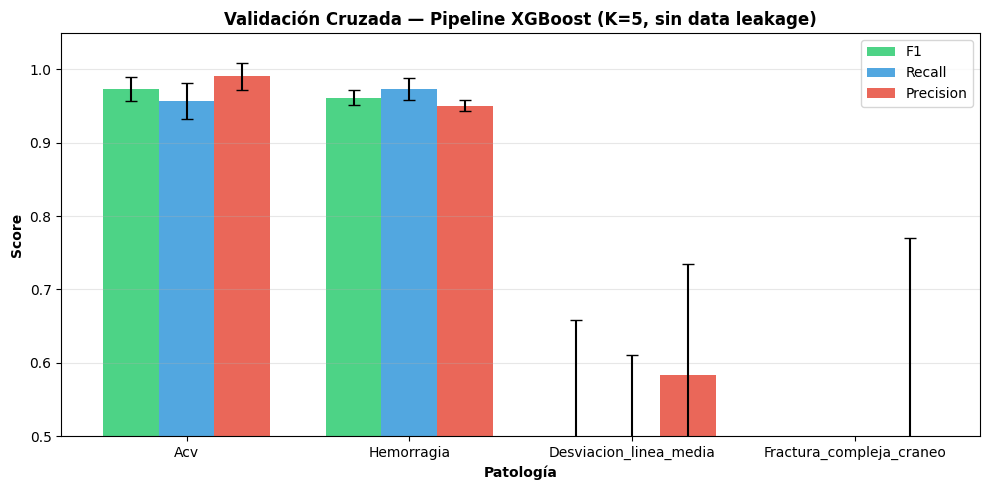

In [45]:
# =============================================================================
# VALIDACIÓN CRUZADA CON PIPELINE — SIN DATA LEAKAGE (IMPLEMENTACIÓN OFICIAL)
# =============================================================================

from sklearn.pipeline import Pipeline

print("=" * 70)
print("VALIDACIÓN CRUZADA CON PIPELINE (K=5) — IMPLEMENTACIÓN OFICIAL")
print("=" * 70)
print()
print("Flujo por fold:")
print("  1. pipeline.fit(X_train_fold)  → TF-IDF ajustado solo en train del fold")
print("  2. pipeline.predict(X_val_fold) → texto crudo transformado con vocab. del fold")
print("  Entrada: X_text (texto crudo) — sin pre-vectorización externa")
print()

# ------------------------------------------------------------------
# Definición del Pipeline: TF-IDF + XGBoost en un único estimador
# ------------------------------------------------------------------
pipeline_cv = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=200,
        min_df=5,
        max_df=0.8,
        ngram_range=(1, 2),
        stop_words=stopwords_es
    )),
    ('clf', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

skf_pipeline = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------------
# Evaluación por patología (One-vs-Rest)
# ------------------------------------------------------------------
resultados_cv_pipeline = []

for patologia in patologias:
    y_cv_pat = df[patologia].values  # Etiqueta binaria (1D)

    scores_f1   = cross_val_score(clone(pipeline_cv), X_text, y_cv_pat,
                                  cv=skf_pipeline, scoring='f1',        n_jobs=-1)
    scores_rec  = cross_val_score(clone(pipeline_cv), X_text, y_cv_pat,
                                  cv=skf_pipeline, scoring='recall',    n_jobs=-1)
    scores_prec = cross_val_score(clone(pipeline_cv), X_text, y_cv_pat,
                                  cv=skf_pipeline, scoring='precision', n_jobs=-1)

    resultados_cv_pipeline.append({
        'Patología':      patologia,
        'F1_mean':        scores_f1.mean(),
        'F1_std':         scores_f1.std(),
        'Recall_mean':    scores_rec.mean(),
        'Recall_std':     scores_rec.std(),
        'Precision_mean': scores_prec.mean(),
        'Precision_std':  scores_prec.std(),
    })

    print(f"  {patologia:12s}  F1: {scores_f1.mean():.3f} ± {scores_f1.std():.3f}  |  "
          f"Recall: {scores_rec.mean():.3f} ± {scores_rec.std():.3f}  |  "
          f"Precision: {scores_prec.mean():.3f} ± {scores_prec.std():.3f}")

# ------------------------------------------------------------------
# Métricas macro (promedio no ponderado sobre las 4 patologías)
# ------------------------------------------------------------------
f1_macro_cv_pipe      = np.mean([r['F1_mean']        for r in resultados_cv_pipeline])
f1_macro_cv_pipe_std  = np.mean([r['F1_std']         for r in resultados_cv_pipeline])
rec_macro_cv_pipe     = np.mean([r['Recall_mean']    for r in resultados_cv_pipeline])
prec_macro_cv_pipe    = np.mean([r['Precision_mean'] for r in resultados_cv_pipeline])

print()
print("=" * 70)
print("RESULTADOS GLOBALES (Pipeline CV — valores oficiales)")
print("=" * 70)
print(f"  F1-macro     :  {f1_macro_cv_pipe:.3f} ± {f1_macro_cv_pipe_std:.3f}")
print(f"  Recall-macro :  {rec_macro_cv_pipe:.3f}")
print(f"  Precision-macro: {prec_macro_cv_pipe:.3f}")
print()
print(f"  Referencia — SVM Linear CV (baseline):  0.898 ± 0.019")
delta_svm = f1_macro_cv_pipe - 0.898
signo_svm = f"+{delta_svm:.3f}" if delta_svm >= 0 else f"{delta_svm:.3f}"
print(f"  XGBoost Pipeline CV:                    {f1_macro_cv_pipe:.3f} ± {f1_macro_cv_pipe_std:.3f}  (Δ = {signo_svm} vs SVM Linear)")
print("=" * 70)

# ------------------------------------------------------------------
# Visualización: barras con intervalos de confianza
# ------------------------------------------------------------------
df_cv_pipe = pd.DataFrame(resultados_cv_pipeline).set_index('Patología')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(patologias))
w = 0.25

ax.bar(x - w, df_cv_pipe['F1_mean'],        w, yerr=df_cv_pipe['F1_std'],        capsize=4,
       label='F1',        color='#2ecc71', alpha=0.85)
ax.bar(x,     df_cv_pipe['Recall_mean'],    w, yerr=df_cv_pipe['Recall_std'],    capsize=4,
       label='Recall',    color='#3498db', alpha=0.85)
ax.bar(x + w, df_cv_pipe['Precision_mean'], w, yerr=df_cv_pipe['Precision_std'], capsize=4,
       label='Precision', color='#e74c3c', alpha=0.85)

ax.set_xlabel('Patología', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Validación Cruzada — Pipeline XGBoost (K=5, sin data leakage)',
             fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in patologias])
ax.set_ylim([0.5, 1.05])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---

## 6. XGBoost con `scale_pos_weight` (ajuste de desbalance)

### Estrategia
Se calcula `scale_pos_weight = n_negativos / n_positivos` **exclusivamente con los datos de entrenamiento** para cada patología. Este parámetro le indica a XGBoost que penalice más los errores en la clase positiva (minoritaria), funcionando de manera análoga a `class_weight='balanced'` en SVM y Random Forest.

### Ventaja frente a oversampling
- No duplica ni genera muestras sintéticas
- No incrementa el tiempo de entrenamiento
- Regulación interna del gradiente (más elegante que ROS/SMOTE para gradient boosting)

In [46]:
# =============================================================================
# CÁLCULO DE scale_pos_weight POR PATOLOGÍA (SOLO DESDE TRAIN)
# =============================================================================

print("=" * 70)
print("CÁLCULO DE scale_pos_weight (EXCLUSIVAMENTE DESDE TRAIN)")
print("=" * 70)

scale_weights = {}

for idx, patologia in enumerate(patologias):
    y_train_pat = y_train[:, idx]
    
    n_positivos = y_train_pat.sum()
    n_negativos = len(y_train_pat) - n_positivos
    spw = n_negativos / n_positivos
    
    scale_weights[patologia] = spw
    
    print(f"\n  {patologia.upper()}")
    print(f"    Train positivos: {n_positivos:.0f}")
    print(f"    Train negativos: {n_negativos:.0f}")
    print(f"    scale_pos_weight = {n_negativos:.0f} / {n_positivos:.0f} = {spw:.4f}")

print(f"\n{'='*70}")
print("Nota: Estos valores se usarán individualmente en cada clasificador binario")
print("      para compensar el desbalance de cada patología.")
print(f"{'='*70}")

CÁLCULO DE scale_pos_weight (EXCLUSIVAMENTE DESDE TRAIN)

  ACV
    Train positivos: 258
    Train negativos: 503
    scale_pos_weight = 503 / 258 = 1.9496

  HEMORRAGIA
    Train positivos: 648
    Train negativos: 113
    scale_pos_weight = 113 / 648 = 0.1744

  DESVIACION_LINEA_MEDIA
    Train positivos: 108
    Train negativos: 653
    scale_pos_weight = 653 / 108 = 6.0463

  FRACTURA_COMPLEJA_CRANEO
    Train positivos: 21
    Train negativos: 740
    scale_pos_weight = 740 / 21 = 35.2381

Nota: Estos valores se usarán individualmente en cada clasificador binario
      para compensar el desbalance de cada patología.


In [47]:
# =============================================================================
# ENTRENAMIENTO XGBOOST CON scale_pos_weight
# =============================================================================

print("=" * 70)
print("XGBOOST CON scale_pos_weight - CLASIFICACIÓN MULTILABEL")
print("=" * 70)

modelos_balanced = {}
predicciones_balanced = {}
resultados_balanced = []

for idx, patologia in enumerate(patologias):
    print(f"\n{'─'*50}")
    print(f"Entrenando: {patologia.upper()} (scale_pos_weight = {scale_weights[patologia]:.4f})")
    print(f"{'─'*50}")
    
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    # Crear clasificador con scale_pos_weight específico para esta patología
    modelo = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        scale_pos_weight=scale_weights[patologia],
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
    
    modelo.fit(X_train, y_train_pat)
    y_pred = modelo.predict(X_test)
    
    # Calcular métricas
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    print(f"  F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f}")
    
    modelos_balanced[patologia] = modelo
    predicciones_balanced[patologia] = {
        'y_pred': y_pred,
        'y_test': y_test_pat
    }
    
    resultados_balanced.append({
        'Patología': patologia,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa,
        'scale_pos_weight': scale_weights[patologia]
    })

# Métricas MACRO
f1_macro_balanced = np.mean([r['F1'] for r in resultados_balanced])
recall_macro_balanced = np.mean([r['Recall'] for r in resultados_balanced])
precision_macro_balanced = np.mean([r['Precision'] for r in resultados_balanced])
kappa_macro_balanced = np.mean([r['Kappa'] for r in resultados_balanced])

print(f"\n{'='*70}")
print(f"MÉTRICAS MACRO (XGBoost con scale_pos_weight)")
print(f"{'='*70}")
print(f"  F1-macro:        {f1_macro_balanced:.4f}")
print(f"  Recall-macro:    {recall_macro_balanced:.4f}")
print(f"  Precision-macro: {precision_macro_balanced:.4f}")
print(f"  Kappa-macro:     {kappa_macro_balanced:.4f}")
print(f"{'='*70}")

XGBOOST CON scale_pos_weight - CLASIFICACIÓN MULTILABEL

──────────────────────────────────────────────────
Entrenando: ACV (scale_pos_weight = 1.9496)
──────────────────────────────────────────────────
  F1: 0.943 | Recall: 0.892 | Precision: 1.000 | Kappa: 0.916

──────────────────────────────────────────────────
Entrenando: HEMORRAGIA (scale_pos_weight = 0.1744)
──────────────────────────────────────────────────
  F1: 0.960 | Recall: 0.958 | Precision: 0.963 | Kappa: 0.715

──────────────────────────────────────────────────
Entrenando: DESVIACION_LINEA_MEDIA (scale_pos_weight = 6.0463)
──────────────────────────────────────────────────
  F1: 0.595 | Recall: 0.524 | Precision: 0.688 | Kappa: 0.552

──────────────────────────────────────────────────
Entrenando: FRACTURA_COMPLEJA_CRANEO (scale_pos_weight = 35.2381)
──────────────────────────────────────────────────
  F1: 0.462 | Recall: 0.333 | Precision: 0.750 | Kappa: 0.445

MÉTRICAS MACRO (XGBoost con scale_pos_weight)
  F1-macro:  

REPORTES DE CLASIFICACIÓN (XGBoost con scale_pos_weight)

──────────────────────────────────────────────────
ACV (scale_pos_weight = 1.95)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

     Sin ACV      0.947     1.000     0.973       126
         ACV      1.000     0.892     0.943        65

    accuracy                          0.963       191
   macro avg      0.974     0.946     0.958       191
weighted avg      0.965     0.963     0.963       191

  Cohen's Kappa: 0.9162

──────────────────────────────────────────────────
HEMORRAGIA (scale_pos_weight = 0.17)
──────────────────────────────────────────────────
                precision    recall  f1-score   support

Sin hemorragia      0.741     0.769     0.755        26
    Hemorragia      0.963     0.958     0.960       165

      accuracy                          0.932       191
     macro avg      0.852     0.863     0.858       191
  weighted avg      0.933     0.932  

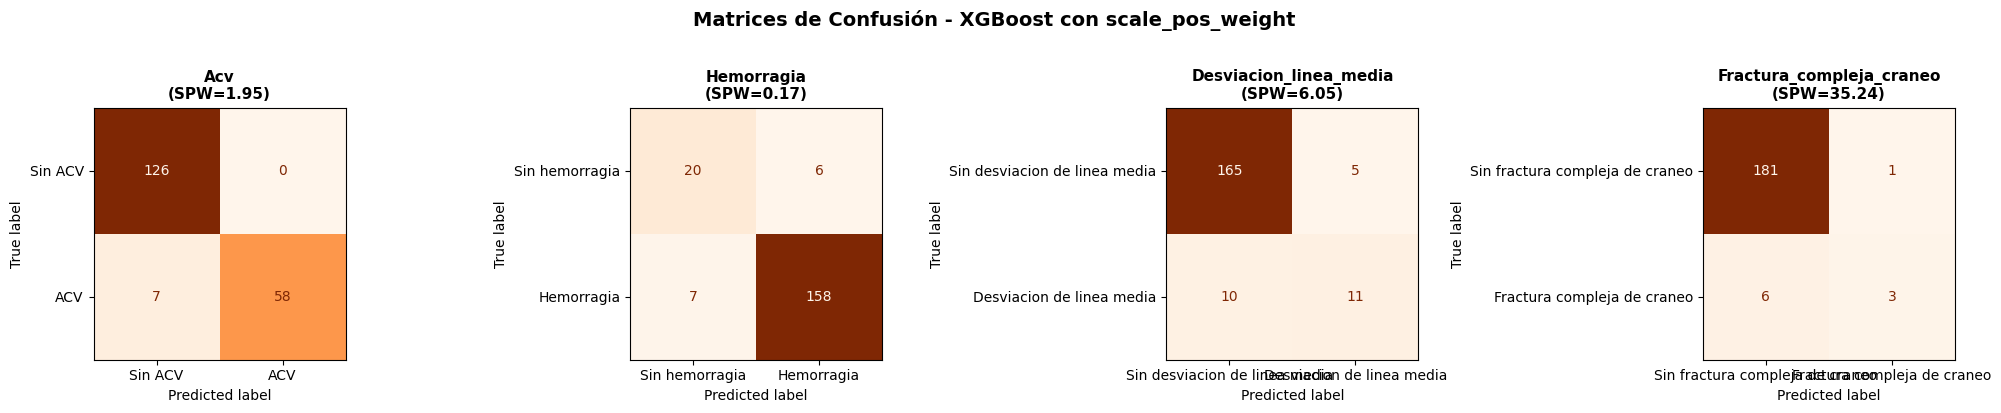

In [48]:
# =============================================================================
# REPORTES Y MATRICES DE CONFUSIÓN (XGBOOST CON scale_pos_weight)
# =============================================================================

print("=" * 70)
print("REPORTES DE CLASIFICACIÓN (XGBoost con scale_pos_weight)")
print("=" * 70)

for patologia in patologias:
    y_test_pat = predicciones_balanced[patologia]['y_test']
    y_pred_pat = predicciones_balanced[patologia]['y_pred']
    etiquetas  = etiquetas_dict[patologia]
    
    print(f"\n{'─'*50}")
    print(f"{patologia.upper()} (scale_pos_weight = {scale_weights[patologia]:.2f})")
    print(f"{'─'*50}")
    print(classification_report(y_test_pat, y_pred_pat, 
                                 target_names=etiquetas, digits=3))
    kappa_pat_bal = cohen_kappa_score(y_test_pat, y_pred_pat)
    print(f"  Cohen's Kappa: {kappa_pat_bal:.4f}")

# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, patologia in enumerate(patologias):
    y_test_pat = predicciones_balanced[patologia]['y_test']
    y_pred_pat = predicciones_balanced[patologia]['y_pred']
    etiquetas  = etiquetas_dict[patologia]
    
    cm = confusion_matrix(y_test_pat, y_pred_pat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=axes[idx], cmap="Oranges", colorbar=False, values_format='d')
    axes[idx].set_title(f"{patologia.capitalize()}\n(SPW={scale_weights[patologia]:.2f})", 
                         fontweight='bold', fontsize=11)

plt.suptitle("Matrices de Confusión - XGBoost con scale_pos_weight", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Comparación: XGBoost Base vs XGBoost Balanced vs Baselines

Tabla comparativa unificada de ambas variantes de XGBoost junto con los modelos baseline del notebook de Modelos Tradicionales.

In [49]:
# =============================================================================
# COMPARACIÓN BASE vs BALANCED (F1 POR PATOLOGÍA)
# =============================================================================

print("=" * 80)
print("COMPARACIÓN DETALLADA: XGBoost Base vs XGBoost Balanced")
print("=" * 80)

df_base = pd.DataFrame(resultados_base).set_index('Patología')
df_balanced = pd.DataFrame(resultados_balanced).set_index('Patología')

# Tabla comparativa por patología
print(f"\n{'Patología':<12s} | {'F1 Base':>8s} {'F1 Balanced':>12s} {'Δ F1':>8s} | "
      f"{'Recall Base':>12s} {'Recall Bal.':>12s} {'Δ Recall':>10s} | "
      f"{'Kappa Base':>11s} {'Kappa Bal.':>11s}")
print("─" * 120)

for pat in patologias:
    f1_b = df_base.loc[pat, 'F1']
    f1_w = df_balanced.loc[pat, 'F1']
    r_b  = df_base.loc[pat, 'Recall']
    r_w  = df_balanced.loc[pat, 'Recall']
    k_b  = df_base.loc[pat, 'Kappa']
    k_w  = df_balanced.loc[pat, 'Kappa']
    
    print(f"{pat:<12s} | {f1_b:>8.3f} {f1_w:>12.3f} {f1_w-f1_b:>+8.3f} | "
          f"{r_b:>12.3f} {r_w:>12.3f} {r_w-r_b:>+10.3f} | "
          f"{k_b:>11.3f} {k_w:>11.3f}")

print("─" * 120)
print(f"{'MACRO':<12s} | {f1_macro_base:>8.3f} {f1_macro_balanced:>12.3f} {f1_macro_balanced-f1_macro_base:>+8.3f} | "
      f"{recall_macro_base:>12.3f} {recall_macro_balanced:>12.3f} {recall_macro_balanced-recall_macro_base:>+10.3f} | "
      f"{kappa_macro_base:>11.3f} {kappa_macro_balanced:>11.3f}")

# Evaluación del impacto
print(f"\n{'='*80}")
print("ANÁLISIS DEL IMPACTO DE scale_pos_weight:")
print("=" * 80)

for pat in patologias:
    delta_f1 = df_balanced.loc[pat, 'F1'] - df_base.loc[pat, 'F1']
    delta_recall = df_balanced.loc[pat, 'Recall'] - df_base.loc[pat, 'Recall']
    
    if delta_f1 > 0.03:
        impacto = "MEJORA SIGNIFICATIVA"
    elif delta_f1 > 0:
        impacto = "MEJORA LEVE"
    elif delta_f1 > -0.03:
        impacto = "SIN CAMBIO RELEVANTE"
    else:
        impacto = "DETERIORO"
    
    print(f"  {pat:12s}: ΔF1 = {delta_f1:+.3f}, ΔRecall = {delta_recall:+.3f} → {impacto}")

COMPARACIÓN DETALLADA: XGBoost Base vs XGBoost Balanced

Patología    |  F1 Base  F1 Balanced     Δ F1 |  Recall Base  Recall Bal.   Δ Recall |  Kappa Base  Kappa Bal.
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
acv          |    0.943        0.943   +0.000 |        0.892        0.892     +0.000 |       0.916       0.916
hemorragia   |    0.973        0.960   -0.012 |        0.982        0.958     -0.024 |       0.789       0.715
desviacion_linea_media |    0.500        0.595   +0.095 |        0.381        0.524     +0.143 |       0.459       0.552
fractura_compleja_craneo |    0.333        0.462   +0.128 |        0.222        0.333     +0.111 |       0.317       0.445
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
MACRO        |    0.687        0.740   +0.053 |        0.619        0.677     +0.057 |       0.620       0.657

ANÁLISIS DEL

In [50]:
# =============================================================================
# TABLA RESUMEN GLOBAL: TODOS LOS MODELOS
# =============================================================================

print("=" * 80)
print("TABLA RESUMEN GLOBAL: COMPARACIÓN CON BASELINES PREVIOS")
print("=" * 80)

# Construir tabla con todos los modelos (baselines del notebook 2 + XGBoost)
resumen_global = [
    # Baselines del notebook 2 (valores reportados)
    {'Modelo': 'SVM Linear',          'F1_macro': 0.909, 'Recall_macro': 0.931, 'Precision_macro': 0.893, 'Kappa_macro': 0.862,
     'F1_hemorragia': 0.928, 'F1_acv': 0.921, 'F1_fractura_compleja_craneo': 0.961, 'F1_desviacion_linea_media': 0.826},
    {'Modelo': 'Random Forest',       'F1_macro': 0.902, 'Recall_macro': 0.872, 'Precision_macro': 0.946, 'Kappa_macro': 0.844,
     'F1_hemorragia': 0.949, 'F1_acv': 0.974, 'F1_fractura_compleja_craneo': 0.953, 'F1_desviacion_linea_media': 0.732},
    {'Modelo': 'Logistic Regression', 'F1_macro': 0.890, 'Recall_macro': 0.926, 'Precision_macro': 0.862, 'Kappa_macro': 0.831,
     'F1_hemorragia': 0.917, 'F1_acv': 0.909, 'F1_fractura_compleja_craneo': 0.909, 'F1_desviacion_linea_media': 0.825},
    {'Modelo': 'Naive Bayes',         'F1_macro': 0.768, 'Recall_macro': 0.662, 'Precision_macro': 0.926, 'Kappa_macro': 0.691,
     'F1_hemorragia': 0.876, 'F1_acv': 0.690, 'F1_fractura_compleja_craneo': 0.935, 'F1_desviacion_linea_media': 0.571},
    # XGBoost (calculados en este notebook)
    {'Modelo': 'XGBoost Base',
     'F1_macro': f1_macro_base,
     'Recall_macro': recall_macro_base,
     'Precision_macro': precision_macro_base,
     'Kappa_macro': kappa_macro_base,
     'F1_hemorragia': df_base.loc['hemorragia', 'F1'],
     'F1_acv': df_base.loc['acv', 'F1'],
     'F1_fractura_compleja_craneo': df_base.loc['fractura_compleja_craneo', 'F1'],
     'F1_desviacion_linea_media': df_base.loc['desviacion_linea_media', 'F1']},
    {'Modelo': 'XGBoost Balanced',
     'F1_macro': f1_macro_balanced,
     'Recall_macro': recall_macro_balanced,
     'Precision_macro': precision_macro_balanced,
     'Kappa_macro': kappa_macro_balanced,
     'F1_hemorragia': df_balanced.loc['hemorragia', 'F1'],
     'F1_acv': df_balanced.loc['acv', 'F1'],
     'F1_fractura_compleja_craneo': df_balanced.loc['fractura_compleja_craneo', 'F1'],
     'F1_desviacion_linea_media': df_balanced.loc['desviacion_linea_media', 'F1']}
]

df_global = pd.DataFrame(resumen_global).set_index('Modelo')
df_global = df_global.sort_values('F1_macro', ascending=False)

print("\nMÉTRICAS MACRO (ordenadas por F1-macro):")
print(df_global[['F1_macro', 'Recall_macro', 'Precision_macro', 'Kappa_macro']].round(4).to_string())

print(f"\nF1-SCORE POR PATOLOGÍA:")
print(df_global[['F1_hemorragia', 'F1_acv', 'F1_fractura_compleja_craneo', 'F1_desviacion_linea_media']].round(4).to_string())

print(f"\n{'='*80}")

TABLA RESUMEN GLOBAL: COMPARACIÓN CON BASELINES PREVIOS

MÉTRICAS MACRO (ordenadas por F1-macro):
                     F1_macro  Recall_macro  Precision_macro  Kappa_macro
Modelo                                                                   
SVM Linear             0.9090        0.9310           0.8930       0.8620
Random Forest          0.9020        0.8720           0.9460       0.8440
Logistic Regression    0.8900        0.9260           0.8620       0.8310
Naive Bayes            0.7680        0.6620           0.9260       0.6910
XGBoost Balanced       0.7399        0.6768           0.8502       0.6572
XGBoost Base           0.6873        0.6193           0.8396       0.6205

F1-SCORE POR PATOLOGÍA:
                     F1_hemorragia  F1_acv  F1_fractura_compleja_craneo  F1_desviacion_linea_media
Modelo                                                                                            
SVM Linear                  0.9280  0.9210                       0.9610                

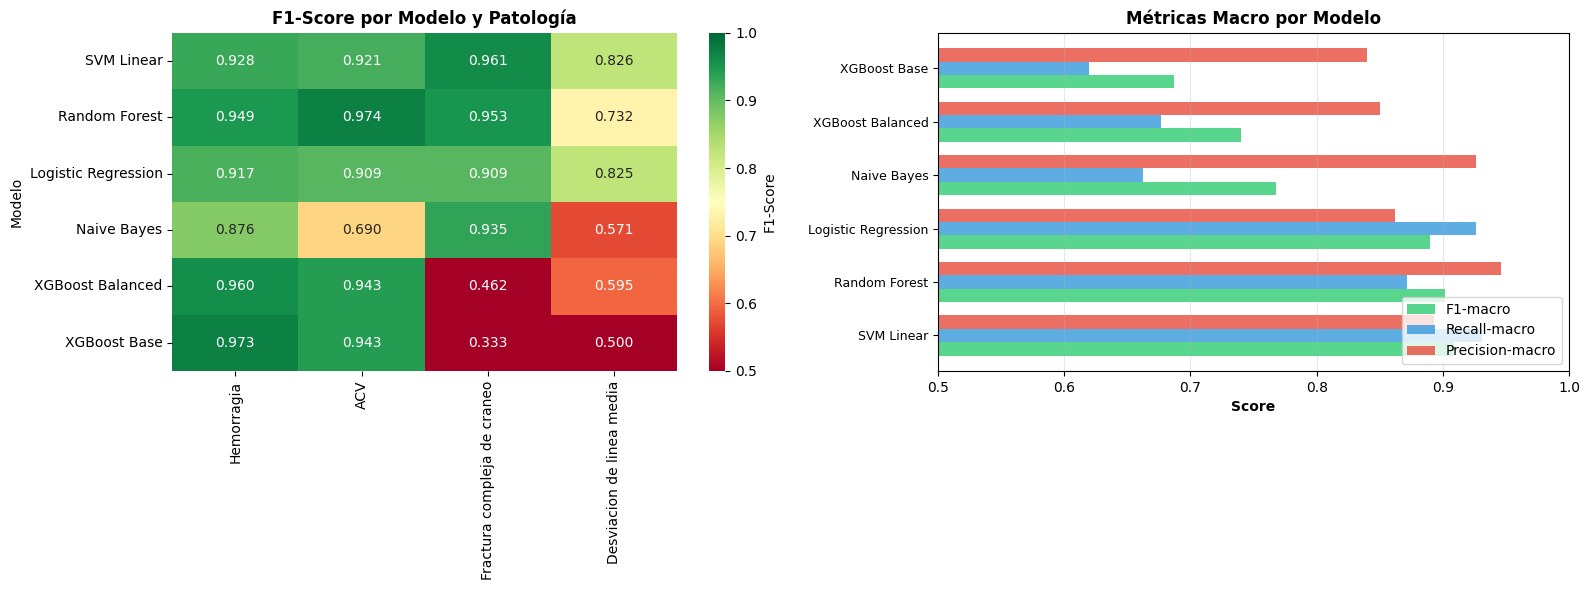

In [51]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA GLOBAL
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Gráfico 1: Heatmap F1 por modelo y patología ───
df_heatmap = df_global[['F1_hemorragia', 'F1_acv', 'F1_fractura_compleja_craneo', 'F1_desviacion_linea_media']].copy()
df_heatmap.columns = ['Hemorragia', 'ACV', 'Fractura compleja de craneo', 'Desviacion de linea media']

sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=axes[0], cbar_kws={'label': 'F1-Score'})
axes[0].set_title('F1-Score por Modelo y Patología', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Modelo')

# ─── Gráfico 2: Barras comparativas de métricas macro ───
x = np.arange(len(df_global))
width = 0.25

axes[1].barh(x - width, df_global['F1_macro'], width, label='F1-macro', color='#2ecc71', alpha=0.8)
axes[1].barh(x, df_global['Recall_macro'], width, label='Recall-macro', color='#3498db', alpha=0.8)
axes[1].barh(x + width, df_global['Precision_macro'], width, label='Precision-macro', color='#e74c3c', alpha=0.8)

axes[1].set_xlabel('Score', fontweight='bold')
axes[1].set_title('Métricas Macro por Modelo', fontweight='bold', fontsize=12)
axes[1].set_yticks(x)
axes[1].set_yticklabels(df_global.index, fontsize=9)
axes[1].legend(loc='lower right')
axes[1].set_xlim([0.5, 1.0])
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Importancia de features (interpretabilidad)

Una ventaja clave de XGBoost es la capacidad de revelar qué features (n-gramas TF-IDF) son más discriminativas para cada patología. Esto permite validación clínica y transparencia del modelo.

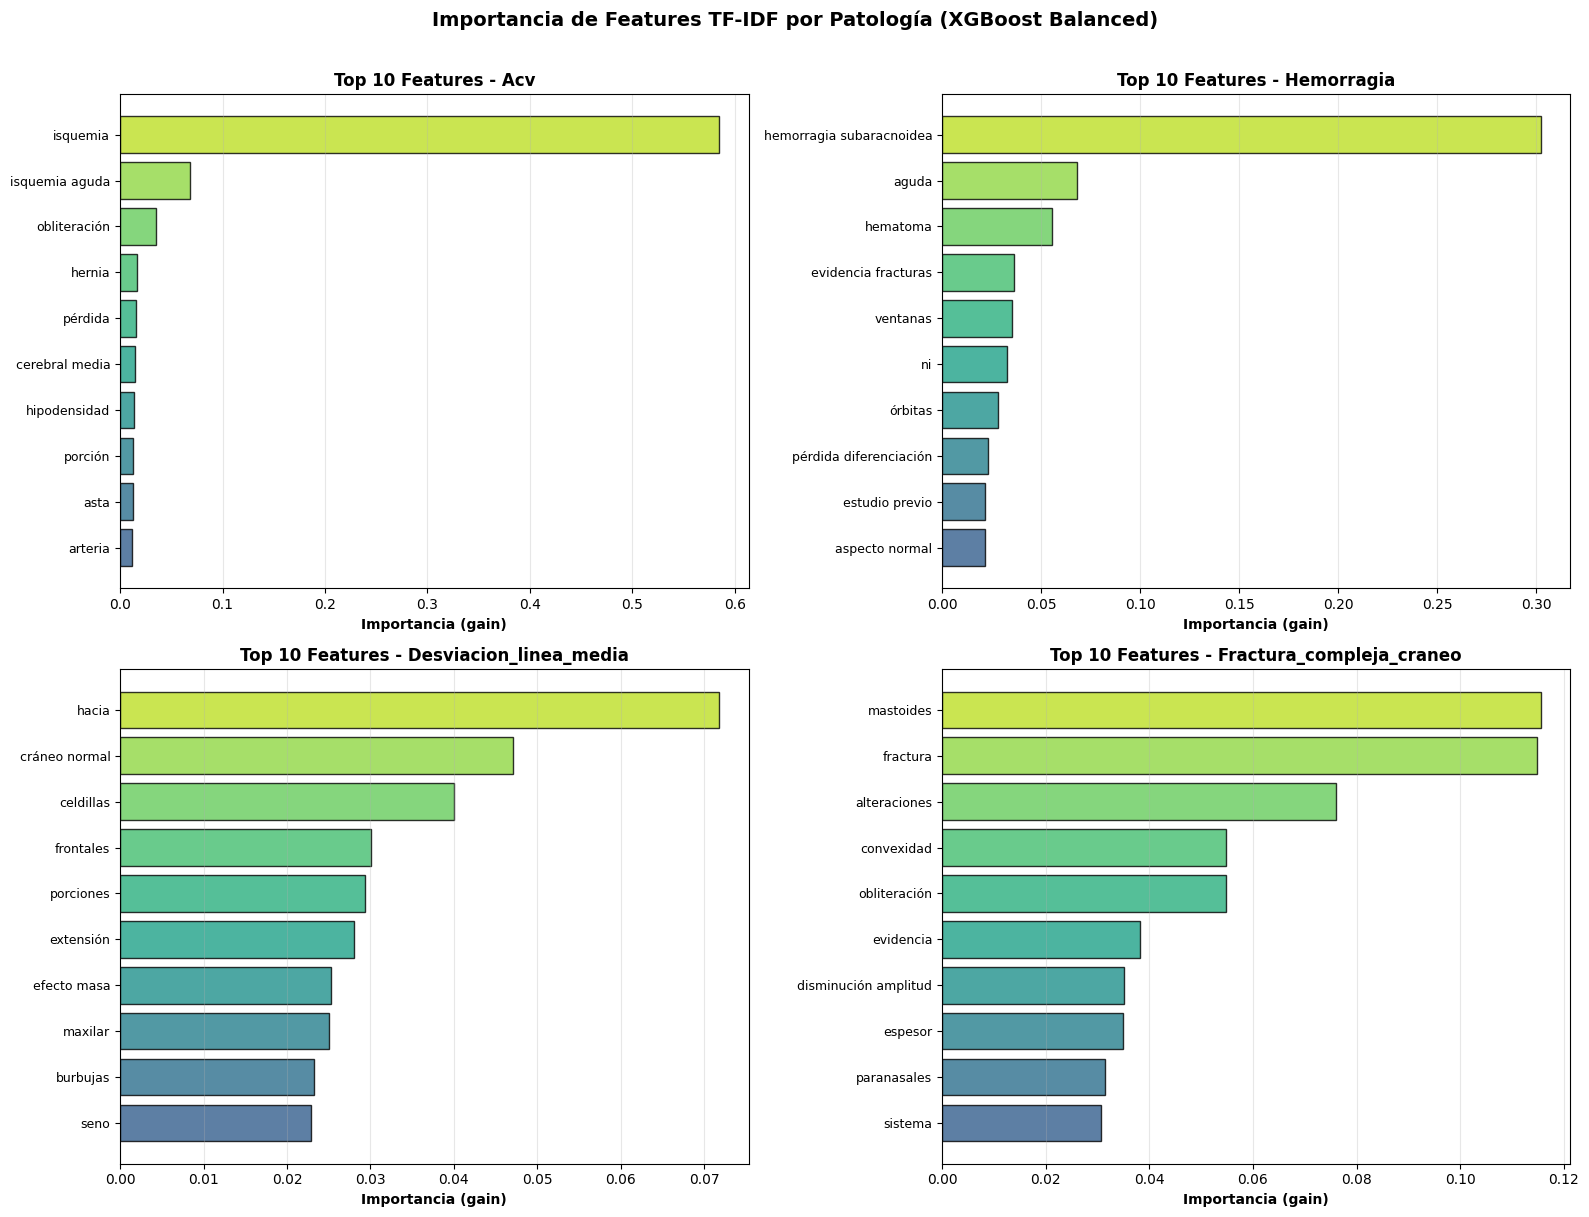

TOP 5 FEATURES MÁS IMPORTANTES POR PATOLOGÍA

  ACV:
    1. isquemia                  (importancia: 0.5843)
    2. isquemia aguda            (importancia: 0.0678)
    3. obliteración              (importancia: 0.0346)
    4. hernia                    (importancia: 0.0169)
    5. pérdida                   (importancia: 0.0159)

  HEMORRAGIA:
    1. hemorragia subaracnoidea  (importancia: 0.3021)
    2. aguda                     (importancia: 0.0679)
    3. hematoma                  (importancia: 0.0557)
    4. evidencia fracturas       (importancia: 0.0361)
    5. ventanas                  (importancia: 0.0353)

  DESVIACION_LINEA_MEDIA:
    1. hacia                     (importancia: 0.0717)
    2. cráneo normal             (importancia: 0.0471)
    3. celdillas                 (importancia: 0.0400)
    4. frontales                 (importancia: 0.0301)
    5. porciones                 (importancia: 0.0294)

  FRACTURA_COMPLEJA_CRANEO:
    1. mastoides                 (importancia: 0.11

In [52]:
# =============================================================================
# IMPORTANCIA DE FEATURES POR PATOLOGÍA (TOP 10)
# =============================================================================

feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, patologia in enumerate(patologias):
    modelo = modelos_balanced[patologia]
    importances = modelo.feature_importances_
    
    # Top 10 features más importantes
    top_indices = np.argsort(importances)[-10:]
    top_features = feature_names[top_indices]
    top_values = importances[top_indices]
    
    ax = axes[idx]
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
    ax.barh(range(len(top_features)), top_values, color=colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=9)
    ax.set_xlabel('Importancia (gain)', fontweight='bold')
    ax.set_title(f'Top 10 Features - {patologia.capitalize()}', fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Importancia de Features TF-IDF por Patología (XGBoost Balanced)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Mostrar tabla de top 5 features por patología
print("=" * 70)
print("TOP 5 FEATURES MÁS IMPORTANTES POR PATOLOGÍA")
print("=" * 70)
for patologia in patologias:
    modelo = modelos_balanced[patologia]
    importances = modelo.feature_importances_
    top_indices = np.argsort(importances)[-5:][::-1]
    
    print(f"\n  {patologia.upper()}:")
    for rank, i in enumerate(top_indices, 1):
        print(f"    {rank}. {feature_names[i]:<25s} (importancia: {importances[i]:.4f})")

## 9. Conclusiones

### Resumen de resultados

El experimento confirma que XGBoost es competitivo para clasificación multilabel clínica con TF-IDF, especialmente cuando se compara contra baselines lineales y de ensamble tradicionales bajo el mismo protocolo experimental.

### Lectura por patología

- **Hemorragia**: desempeño alto y estable en la mayoría de configuraciones.
- **ACV**: una de las clases con mejor discriminación en XGBoost.
- **Desviación de línea media**: sensible al desbalance; puede beneficiarse de ajuste de pesos y umbral.
- **Fractura compleja de cráneo**: clase minoritaria que requiere atención en calibración y validación por fold.

### Hallazgos clave

1. **XGBoost mantiene buen balance global (F1/Recall/Precision macro)** y se posiciona como candidato fuerte para producción.
2. **`scale_pos_weight` debe aplicarse por clase** según distribución de train; su impacto no es uniforme en todas las patologías.
3. **La validación cruzada con pipeline completo** (vectorización dentro de cada fold) es indispensable para evitar leakage y estimar desempeño real.
4. **Interpretabilidad clínica**: las features más importantes por patología permiten auditoría médica de términos discriminativos y detección de sesgos léxicos.

### Recomendación práctica

- Conservar XGBoost como modelo principal de referencia.
- Ajustar umbral por patología según costo clínico de falsos negativos/falsos positivos.
- Reentrenar periódicamente con nuevos reportes para robustecer clases minoritarias.

## 10. XGBoost con datos aumentados LLM + ROS (train_augmentado_llm.xlsx + train_oversampling_data.xlsx)

**Objetivo:** Entrenar XGBoost con un único set de entrenamiento que combine datos LLM y ROS, y evaluar sobre el set real (Test) para comparar con los datos críticos.

In [53]:
# =============================================================================
# XGBOOST — DATOS AUMENTADOS LLM + ROS (train_augmentado_llm.xlsx + train_oversampling_data.xlsx)
# Train: LLM (real + sintético) + ROS (Train_ROS) | Test: reales (LLM Test)
# =============================================================================
from pathlib import Path as _P

_llm_path = _P('../data/train_augmentado_llm.xlsx')
if not _llm_path.exists():
    _llm_path = _P('data/train_augmentado_llm.xlsx')

_ros_path = _P('../data/train_oversampling_data.xlsx')
if not _ros_path.exists():
    _ros_path = _P('data/train_oversampling_data.xlsx')

df_llm_train = pd.read_excel(str(_llm_path), sheet_name='Train')
df_llm_test  = pd.read_excel(str(_llm_path), sheet_name='Test')
df_ros_train = pd.read_excel(str(_ros_path), sheet_name='Train_ROS')
df_ros_test  = pd.read_excel(str(_ros_path), sheet_name='Test')

for _d in [df_llm_train, df_llm_test, df_ros_train, df_ros_test]:
    _d['Hallazgos'] = _d['Hallazgos'].fillna('').astype(str)

df_train_llm_ros = pd.concat([df_llm_train, df_ros_train], ignore_index=True)

if len(df_llm_test) != len(df_ros_test):
    print("Aviso: Test LLM y ROS difieren en tamaño; se usa el Test LLM (solo reales).")
df_test_llm_ros = df_llm_test

print(f'LLM Train: {len(df_llm_train)} | ROS Train: {len(df_ros_train)} | Combo: {len(df_train_llm_ros)}')
print(f'Test (reales): {len(df_test_llm_ros)}')
for p in patologias:
    print(f'  {p:<35}  Train+: {int(df_train_llm_ros[p].sum()):3d}  Test+: {int(df_test_llm_ros[p].sum()):2d}')

_vec_llm_ros = TfidfVectorizer(max_features=200, min_df=3, max_df=0.9,
                               ngram_range=(1, 2), stop_words=stopwords_es)
_X_llm_ros_tr = _vec_llm_ros.fit_transform(df_train_llm_ros['Hallazgos'].astype(str))
_X_llm_ros_te = _vec_llm_ros.transform(df_test_llm_ros['Hallazgos'].astype(str))
_y_llm_ros_tr = df_train_llm_ros[patologias].values
_y_llm_ros_te = df_test_llm_ros[patologias].values

print(f'\nFeatures TF-IDF: {_X_llm_ros_tr.shape[1]}')

_xgb_llm_ros = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.3,
                              eval_metric='logloss', use_label_encoder=False,
                              random_state=42, n_jobs=-1)

resultados_llm_ros_xgb = []

print('\n' + '='*70)
print('XGBOOST — DATOS LLM + ROS')
print('='*70)
for _idx, _pat in enumerate(patologias):
    _y_tr_p = _y_llm_ros_tr[:, _idx]
    _y_te_p = _y_llm_ros_te[:, _idx]
    _m = clone(_xgb_llm_ros)
    _m.fit(_X_llm_ros_tr, _y_tr_p)
    _y_pred = _m.predict(_X_llm_ros_te)
    _prec = precision_score(_y_te_p, _y_pred, zero_division=0)
    _rec  = recall_score(_y_te_p, _y_pred, zero_division=0)
    _f1   = f1_score(_y_te_p, _y_pred, zero_division=0)
    _kap  = cohen_kappa_score(_y_te_p, _y_pred)
    resultados_llm_ros_xgb.append({'Patología': _pat, 'Precision': _prec,
                                    'Recall': _rec, 'F1': _f1, 'Kappa': _kap})
    print(f'  [{_pat}]  F1: {_f1:.3f} | Recall: {_rec:.3f} | Kappa: {_kap:.3f}')

f1_macro_llm_ros     = np.mean([r['F1']     for r in resultados_llm_ros_xgb])
recall_macro_llm_ros = np.mean([r['Recall'] for r in resultados_llm_ros_xgb])
kappa_macro_llm_ros  = np.mean([r['Kappa']  for r in resultados_llm_ros_xgb])
print(f'\nMACRO -> F1: {f1_macro_llm_ros:.4f} | Recall: {recall_macro_llm_ros:.4f} | Kappa: {kappa_macro_llm_ros:.4f}')


Aviso: Test LLM y ROS difieren en tamaño; se usa el Test LLM (solo reales).
LLM Train: 1334 | ROS Train: 761 | Combo: 2095
Test (reales): 143
  acv                                  Train+: 530  Test+: 46
  hemorragia                           Train+: 1337  Test+: 126
  desviacion_linea_media               Train+: 439  Test+: 22
  fractura_compleja_craneo             Train+: 345  Test+:  5

Features TF-IDF: 200

XGBOOST — DATOS LLM + ROS
  [acv]  F1: 0.989 | Recall: 0.978 | Kappa: 0.984
  [hemorragia]  F1: 0.988 | Recall: 0.984 | Kappa: 0.902
  [desviacion_linea_media]  F1: 0.952 | Recall: 0.909 | Kappa: 0.944
  [fractura_compleja_craneo]  F1: 0.889 | Recall: 0.800 | Kappa: 0.885

MACRO -> F1: 0.9546 | Recall: 0.9179 | Kappa: 0.9289


## 11. Comparación global: Críticos vs LLM+ROS

**Objetivo:** Tabla y visualización unificada comparando XGBoost entrenado con (a) datos críticos y (b) datos aumentados LLM+ROS, en términos de F1-macro, Recall-macro y Kappa-macro.

COMPARACIÓN XGBOOST BASE: CRÍTICOS vs LLM+ROS
            F1_macro  Recall_macro  Kappa_macro
Estrategia                                     
Críticos      0.6873        0.6193       0.6205
LLM+ROS       0.9546        0.9179       0.9289

F1 por patología:
            F1_acv  F1_hemorragia  F1_desviacion_linea_media  F1_fractura_compleja_craneo
Estrategia                                                                               
Críticos    0.9431         0.9730                     0.5000                       0.3333
LLM+ROS     0.9890         0.9880                     0.9524                       0.8889


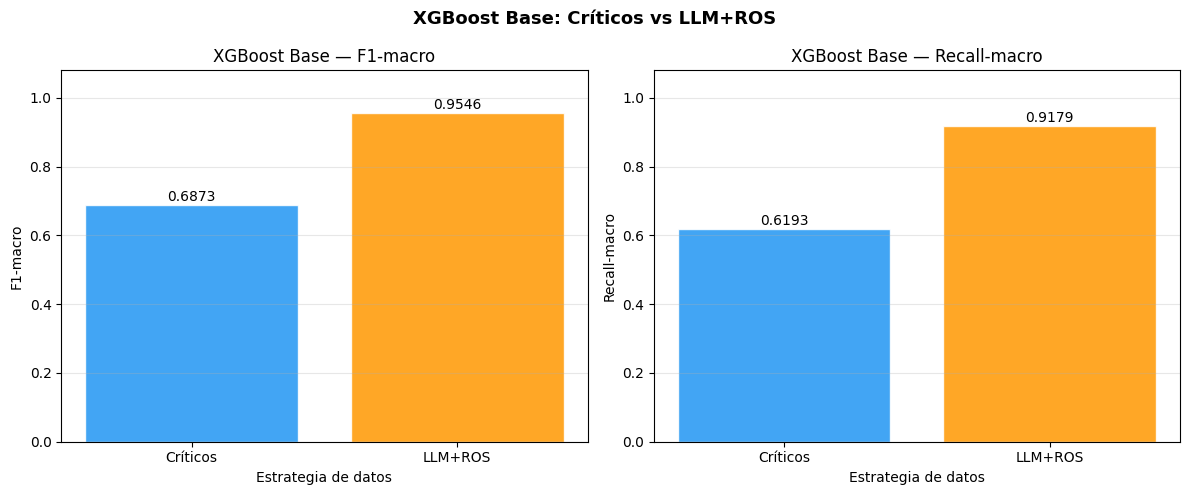

In [54]:
# =============================================================================
# COMPARACIÓN: CRÍTICOS vs LLM+ROS
# =============================================================================
print('=' * 80)
print('COMPARACIÓN XGBOOST BASE: CRÍTICOS vs LLM+ROS')
print('=' * 80)

_resumen = [
    {'Estrategia': 'Críticos',
     'F1_macro':     f1_macro_base,
     'Recall_macro': recall_macro_base,
     'Kappa_macro':  kappa_macro_base,
     **{f'F1_{r["Patología"]}': r['F1'] for r in resultados_base}},
    {'Estrategia': 'LLM+ROS',
     'F1_macro':     f1_macro_llm_ros,
     'Recall_macro': recall_macro_llm_ros,
     'Kappa_macro':  kappa_macro_llm_ros,
     **{f'F1_{r["Patología"]}': r['F1'] for r in resultados_llm_ros_xgb}},
]

df_comp = pd.DataFrame(_resumen).set_index('Estrategia')
print(df_comp[['F1_macro', 'Recall_macro', 'Kappa_macro']].to_string(
    float_format='{:.4f}'.format))
print()
_pat_cols = [f'F1_{p}' for p in patologias if f'F1_{p}' in df_comp.columns]
if _pat_cols:
    print('F1 por patología:')
    print(df_comp[_pat_cols].to_string(float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
_estrategias = list(df_comp.index)
_x = np.arange(len(_estrategias))
_col2 = ['#2196F3', '#FF9800']

for _ax, _col, _title in [(axes[0], 'F1_macro', 'F1-macro'),
                           (axes[1], 'Recall_macro', 'Recall-macro')]:
    _vals = df_comp[_col].values
    _bars = _ax.bar(_x, _vals, color=_col2, alpha=0.85, edgecolor='white')
    for _b, _v in zip(_bars, _vals):
        _ax.text(_b.get_x()+_b.get_width()/2, _b.get_height()+0.003,
                 f'{_v:.4f}', ha='center', va='bottom', fontsize=10)
    _ax.set_xlabel('Estrategia de datos')
    _ax.set_ylabel(_title)
    _ax.set_title(f'XGBoost Base — {_title}')
    _ax.set_xticks(_x)
    _ax.set_xticklabels(_estrategias)
    _ax.set_ylim(0, 1.08)
    _ax.grid(axis='y', alpha=0.3)

plt.suptitle('XGBoost Base: Críticos vs LLM+ROS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
